<a href="https://colab.research.google.com/github/sariyya-aliyeva/Intrusion_Detection_Systems/blob/main/1_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:
!pip install -q gdown

import gdown
import os
import glob
import pandas as pd

folder_id = "1DtuxSKAhI40c9Pko_PKlq4RzJe4sOSVO"

downloaded_files = gdown.download_folder(
    id=folder_id,
    output="/content/CICIDS2017",
    quiet=False,
    use_cookies=False
)

csv_files = sorted(glob.glob("/content/CICIDS2017/*.csv"))

print("CSV files found:")
for f in csv_files:
    print(f)

dfs = []

for file_path in csv_files:
    print("Reading:", os.path.basename(file_path))

    df_temp = pd.read_csv(
        file_path,
        low_memory=False,
        encoding="latin1"
    )

    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

print("\nCombined shape:", df.shape)

df.head()

Retrieving folder contents


Processing file 1HHxV00ausk2GhSSvEm26Yy-4ssPgMhw2 Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Processing file 1pgIDEMKGZK6YNVX6cfAlMMxVKr4kq9qH Friday-WorkingHours-Morning.pcap_ISCX.csv
Processing file 1V6LHS7lWDtF82LgVMLg8-lDIpjugYesp Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1HHxV00ausk2GhSSvEm26Yy-4ssPgMhw2
To: /content/CICIDS2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
100%|██████████| 77.1M/77.1M [00:01<00:00, 72.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1pgIDEMKGZK6YNVX6cfAlMMxVKr4kq9qH
To: /content/CICIDS2017/Friday-WorkingHours-Morning.pcap_ISCX.csv
100%|██████████| 58.3M/58.3M [00:00<00:00, 76.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1V6LHS7lWDtF82LgVMLg8-lDIpjugYesp
To: /content/CICIDS2017/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
100%|██████████| 52.0M/52.0M [00:00<00:00, 67.6MB/s]
Download completed


CSV files found:
/content/CICIDS2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
/content/CICIDS2017/Friday-WorkingHours-Morning.pcap_ISCX.csv
/content/CICIDS2017/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Reading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Reading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Reading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv

Combined shape: (587144, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
df.columns = [col.strip() for col in df.columns]
df["Label"] = df["Label"].astype(str).str.strip()

label_fixes = {
    "Web Attack ï¿½ Brute Force": "Web Attack - Brute Force",
    "Web Attack ï¿½ Sql Injection": "Web Attack - SQL Injection",
    "Web Attack ï¿½ XSS": "Web Attack - XSS",

    "Web Attack � Brute Force": "Web Attack - Brute Force",
    "Web Attack � Sql Injection": "Web Attack - SQL Injection",
    "Web Attack � XSS": "Web Attack - XSS",

    "Web Attack - Sql Injection": "Web Attack - SQL Injection"
}

df["Label"] = df["Label"].replace(label_fixes)

print("Class distribution:")
print(df["Label"].value_counts())

print("\nUnique labels:")
print(df["Label"].unique())

Class distribution:
Label
BENIGN                        454971
DDoS                          128027
Bot                             1966
Web Attack - Brute Force        1507
Web Attack - XSS                 652
Web Attack - SQL Injection        21
Name: count, dtype: int64

Unique labels:
['BENIGN' 'DDoS' 'Bot' 'Web Attack - Brute Force' 'Web Attack - XSS'
 'Web Attack - SQL Injection']


In [ ]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Missing values before imputation:", df.isna().sum().sum())

X = df.drop("Label", axis=1)
y = df["Label"]

imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("Missing values after imputation:", X.isna().sum().sum())
print("Feature count:", X.shape[1])

Missing values before imputation: 582
Missing values after imputation: 0
Feature count: 78


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Encoded classes:
0 -> BENIGN
1 -> Bot
2 -> DDoS
3 -> Web Attack - Brute Force
4 -> Web Attack - SQL Injection
5 -> Web Attack - XSS
Train: (411000, 78)
Validation: (88072, 78)
Test: (88072, 78)


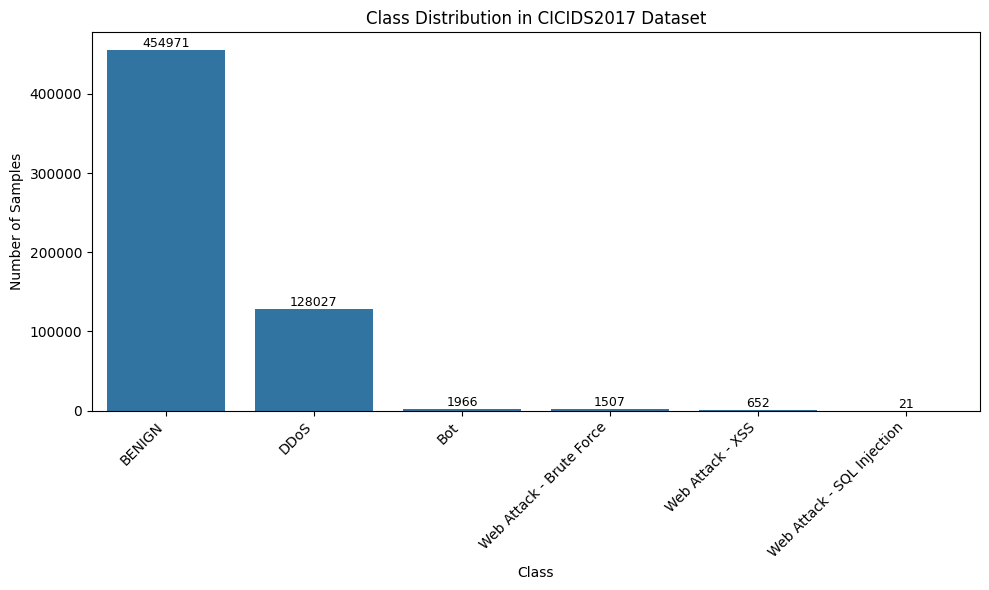

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    x=df["Label"],
    order=df["Label"].value_counts().index
)

plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution in CICIDS2017 Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()